Loaded run: gdv_100_0
Found 48 language_* layers


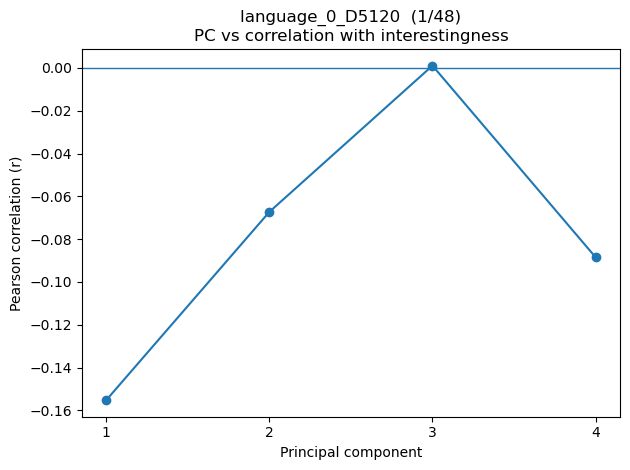

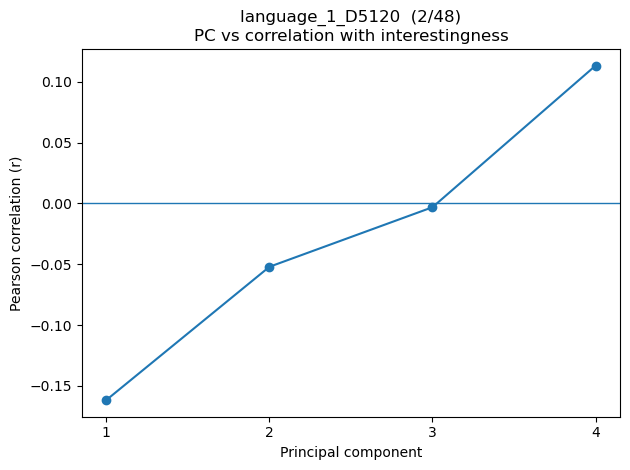

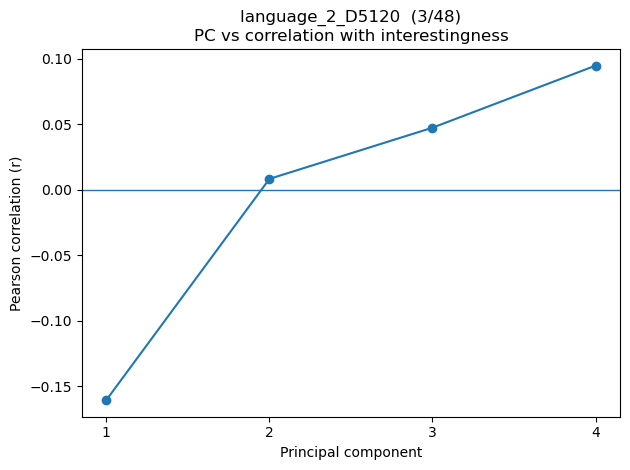

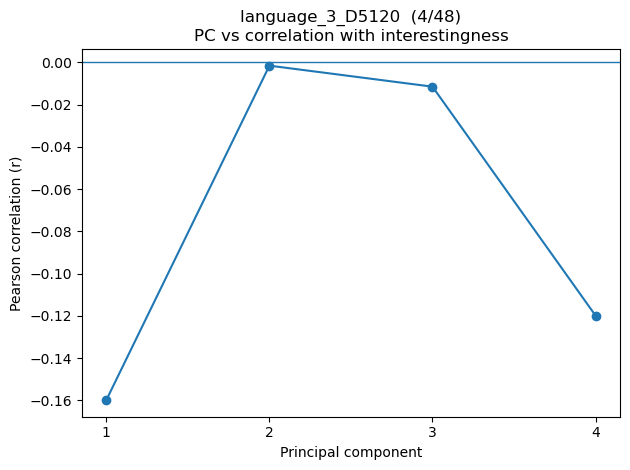

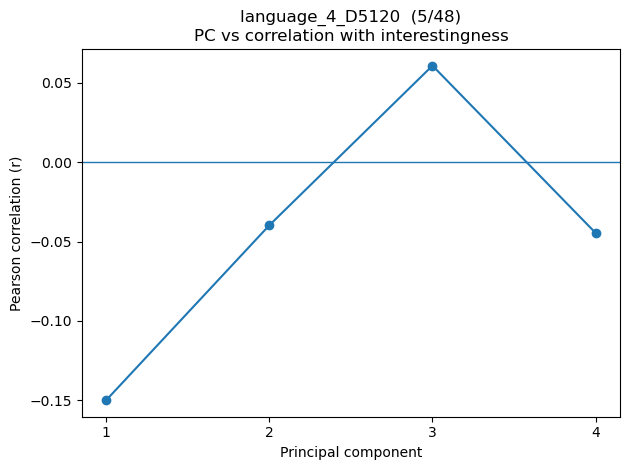

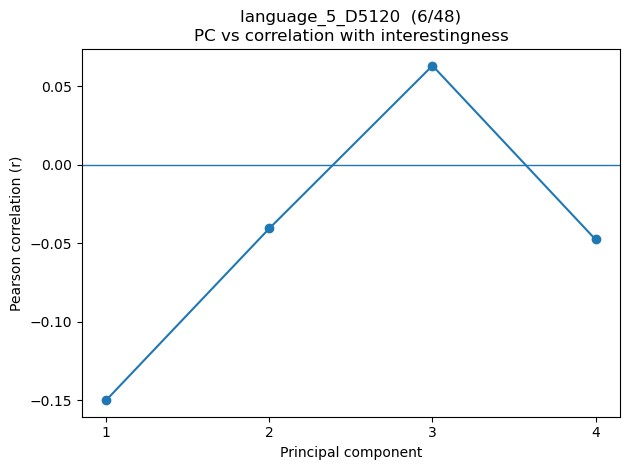

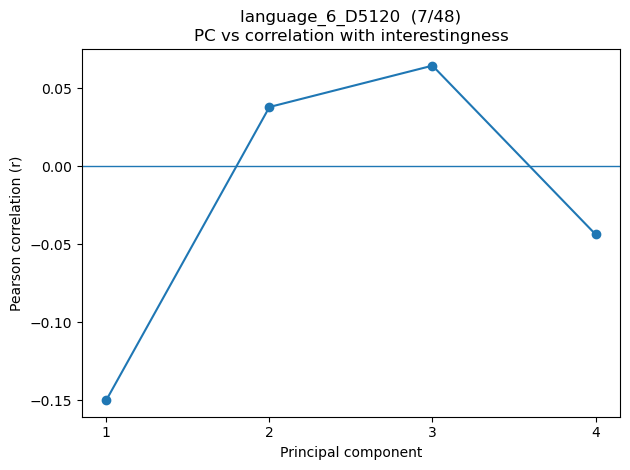

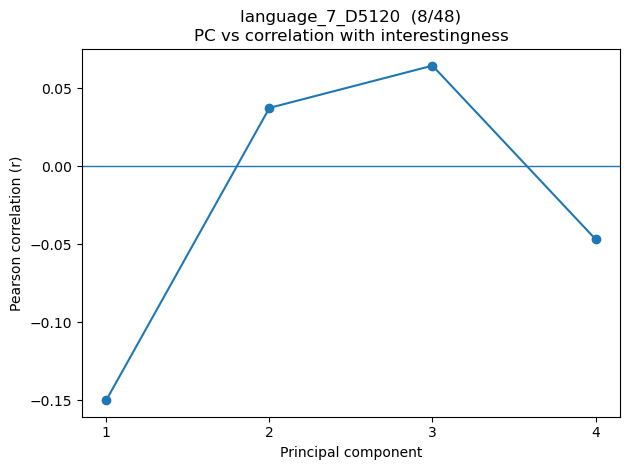

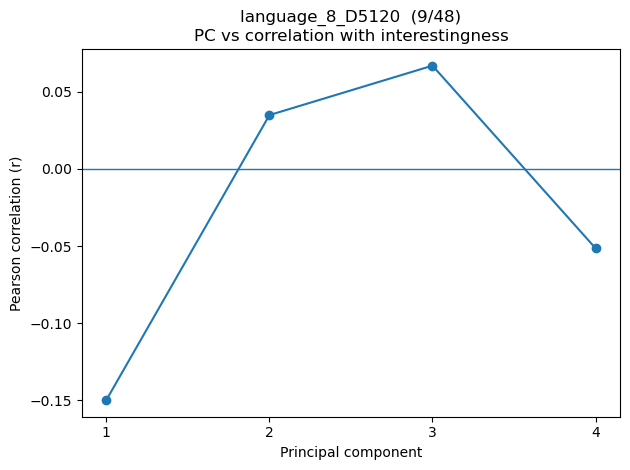

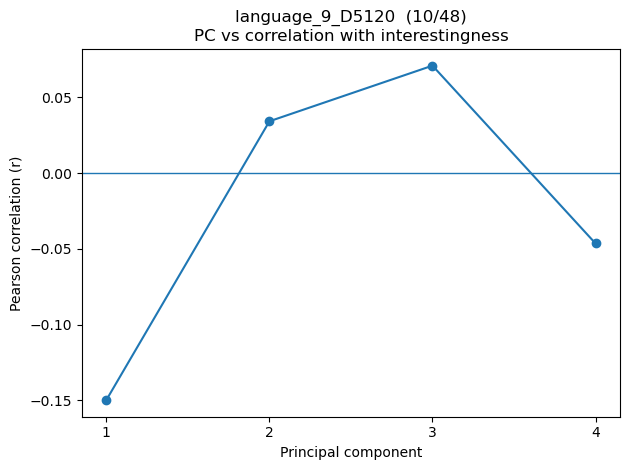

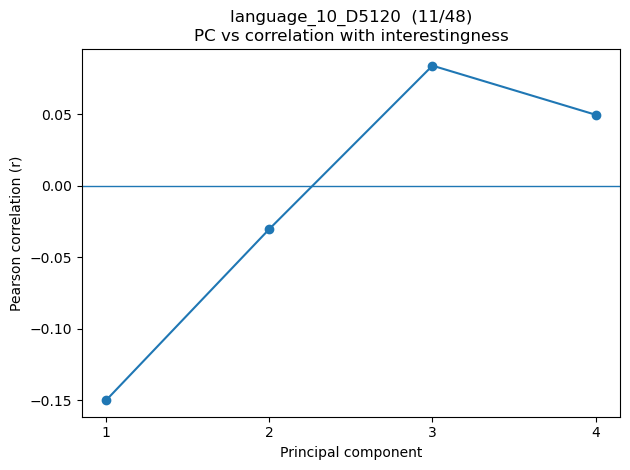

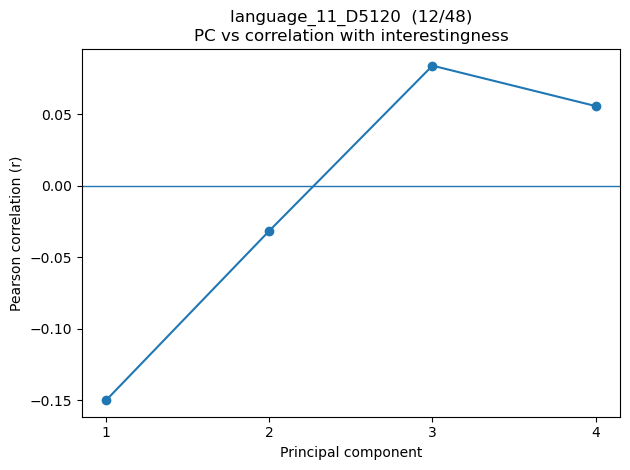

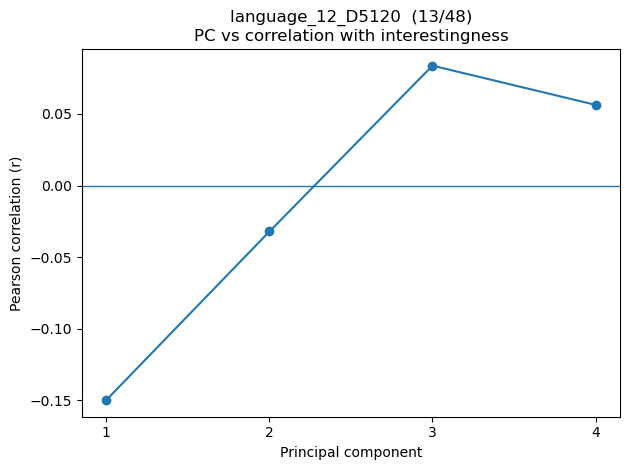

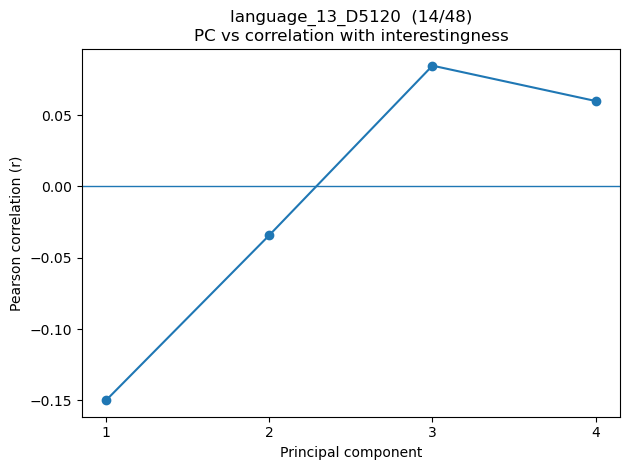

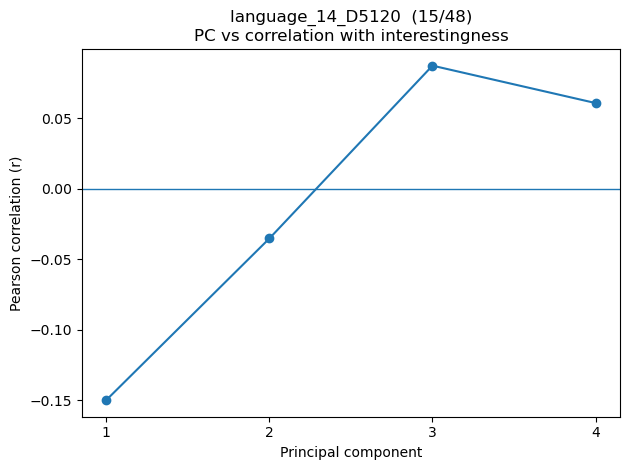

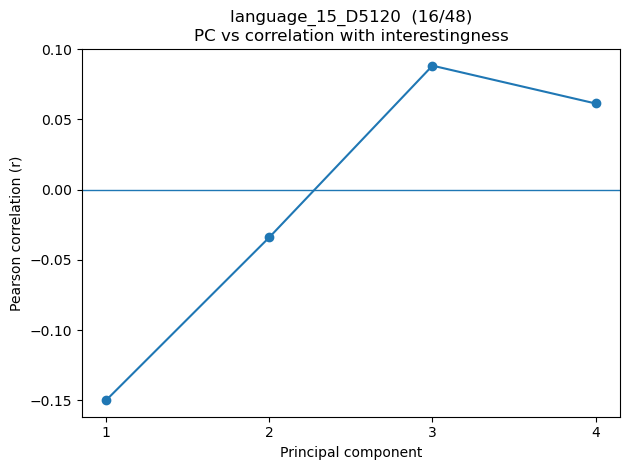

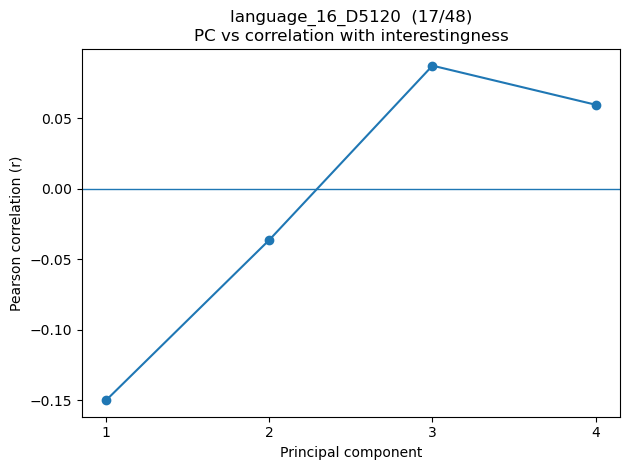

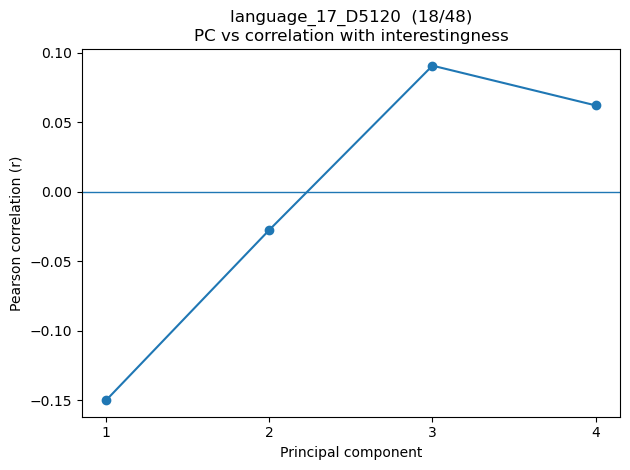

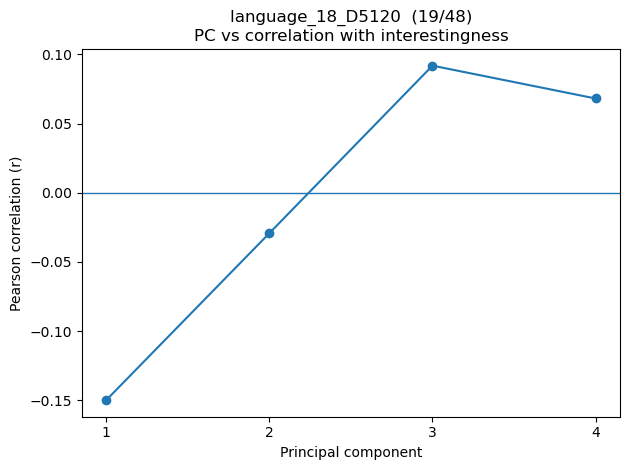

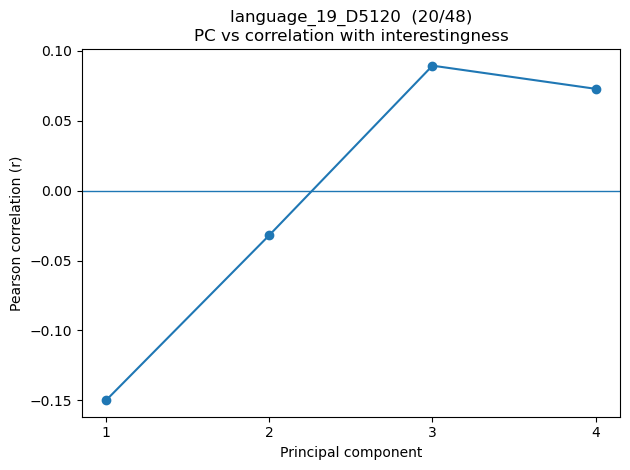

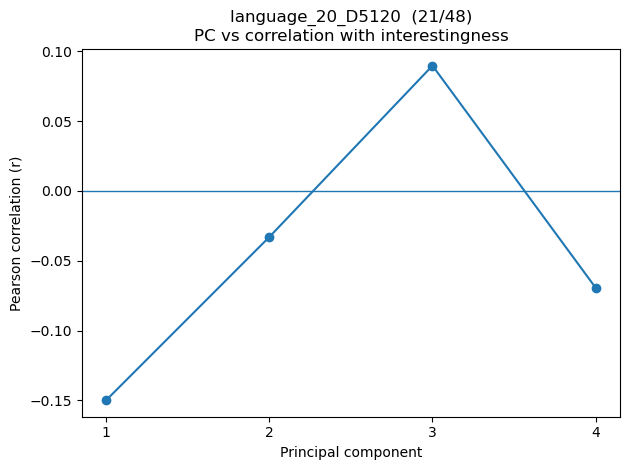

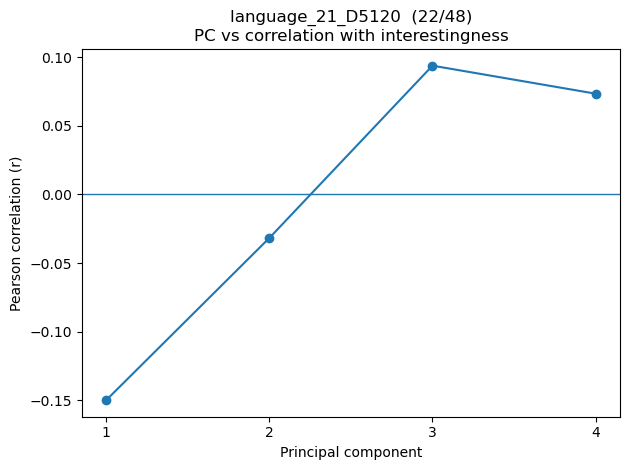

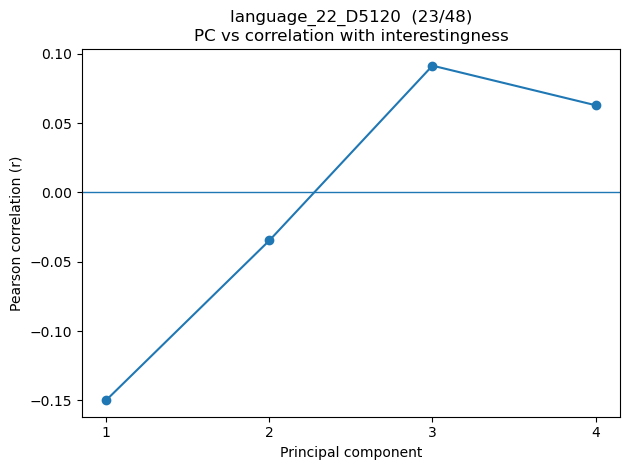

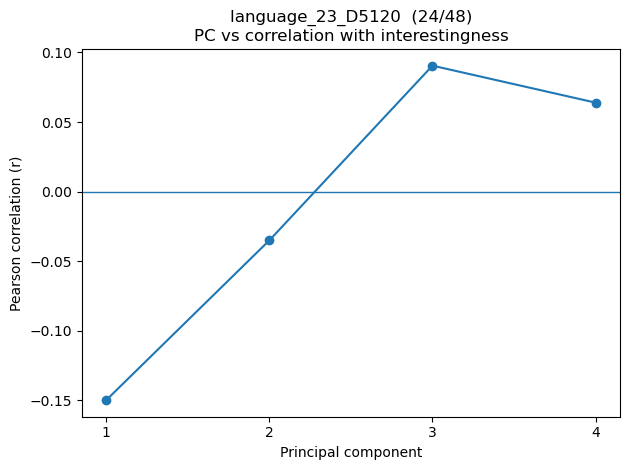

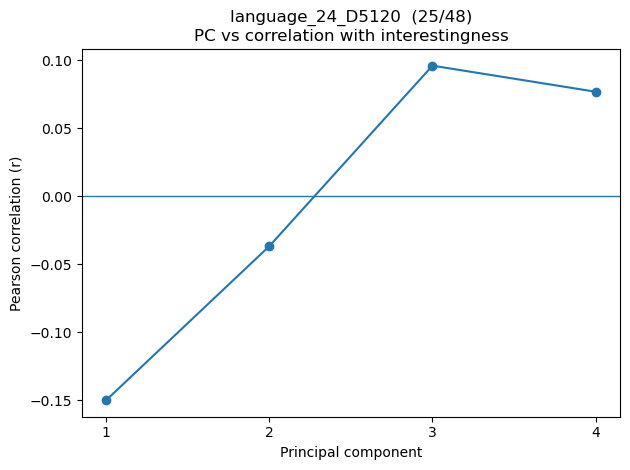

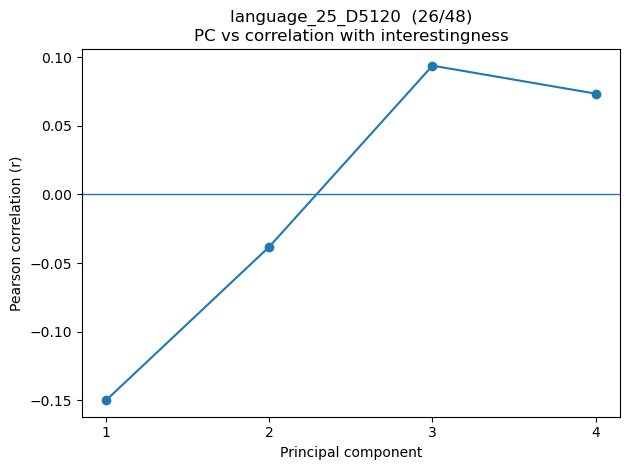

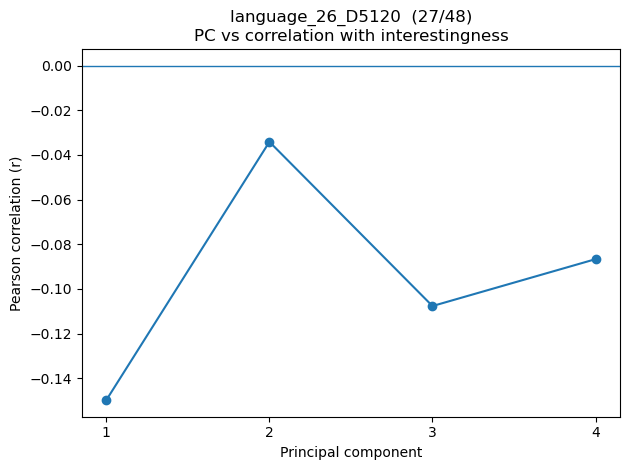

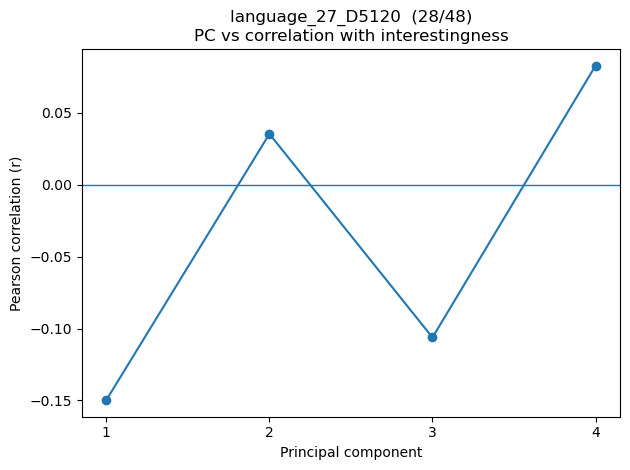

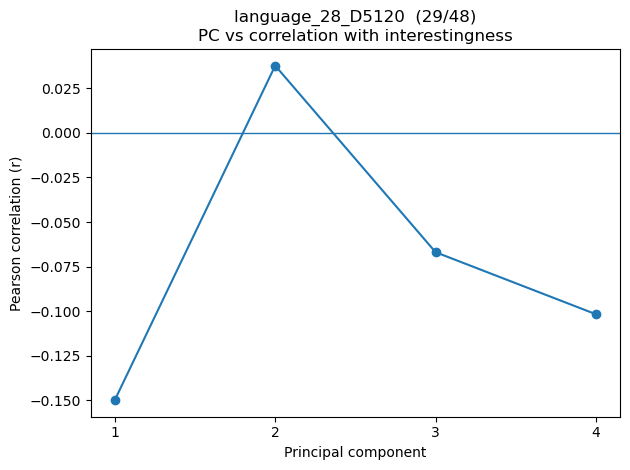

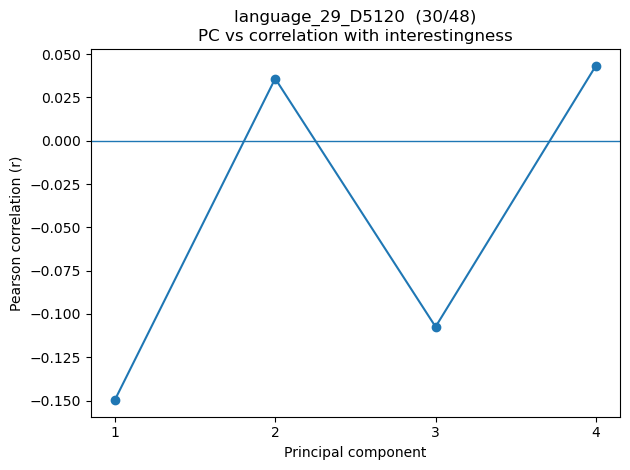

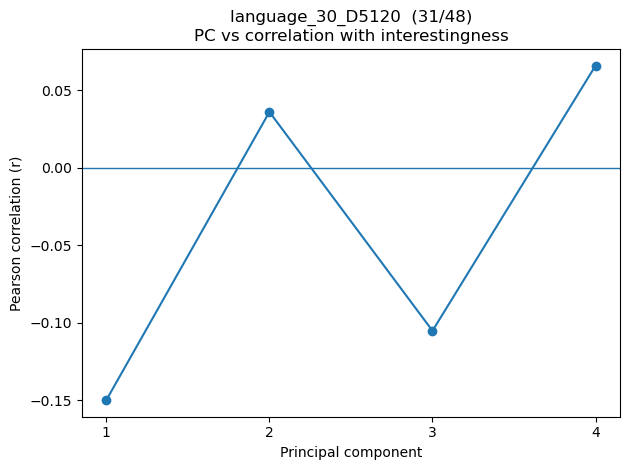

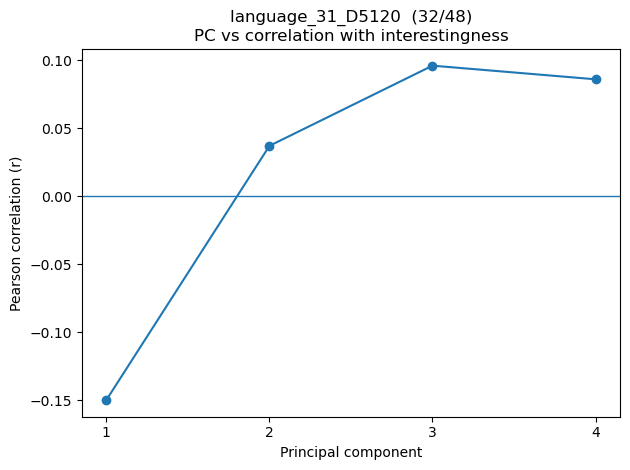

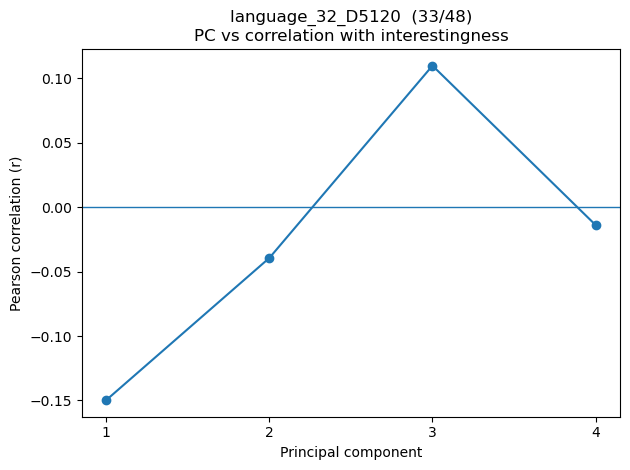

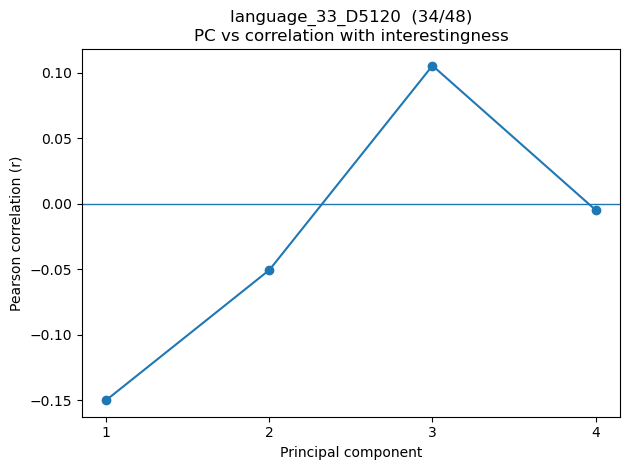

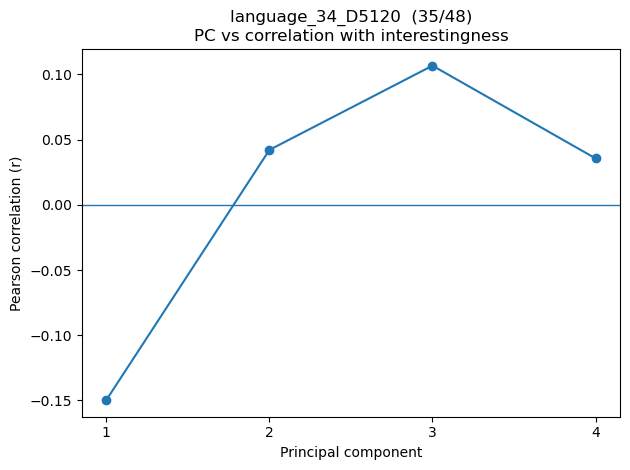

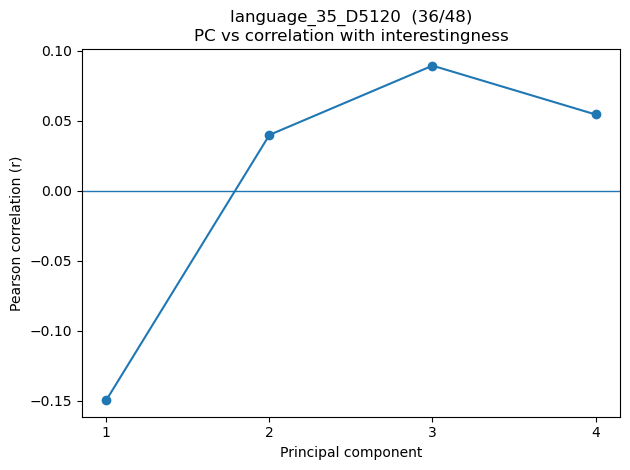

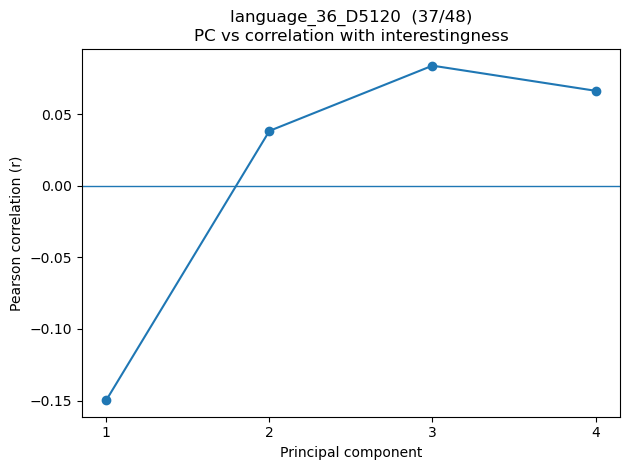

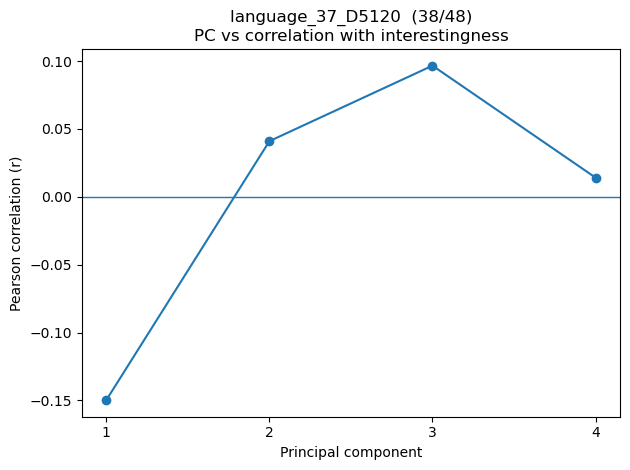

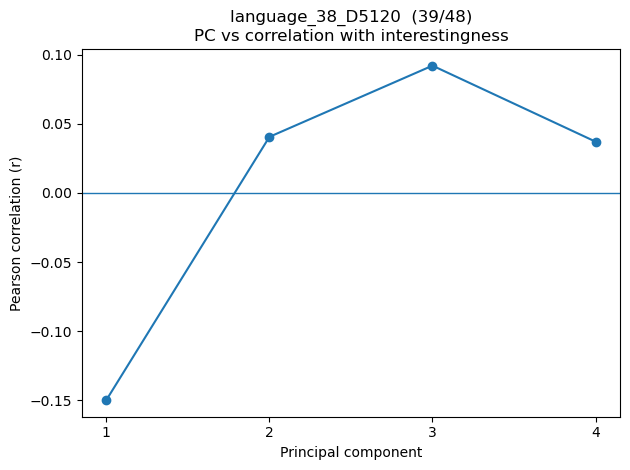

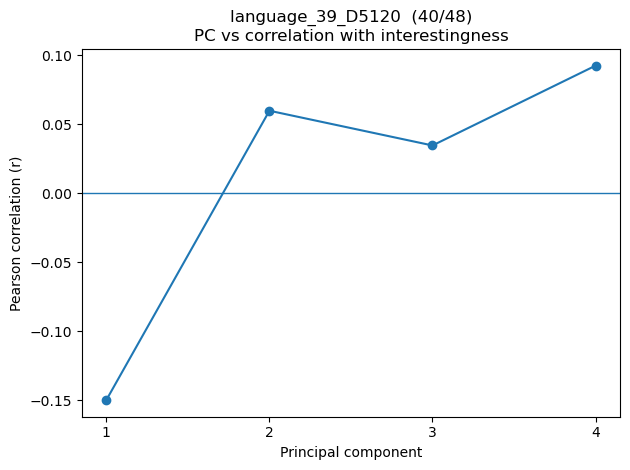

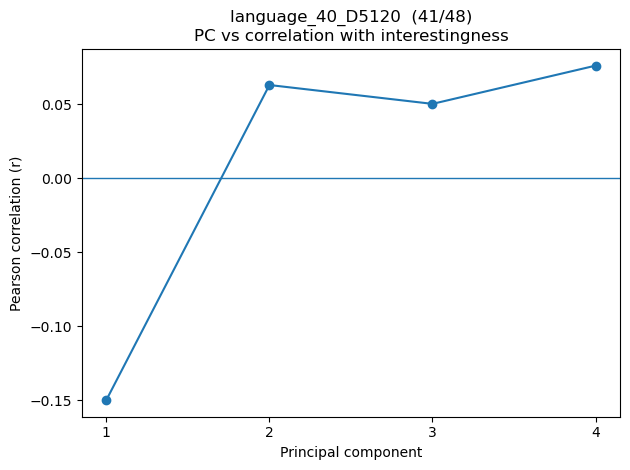

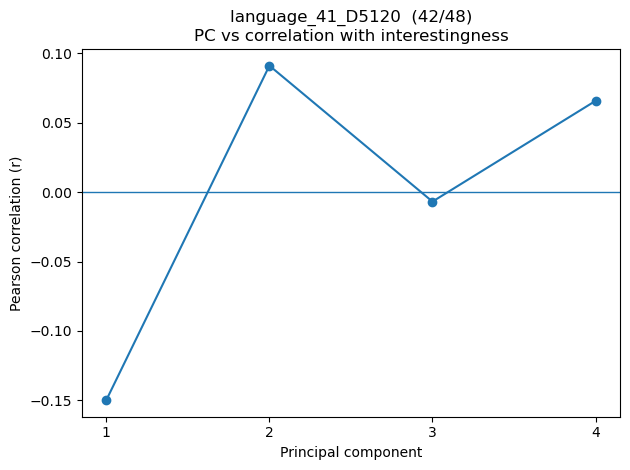

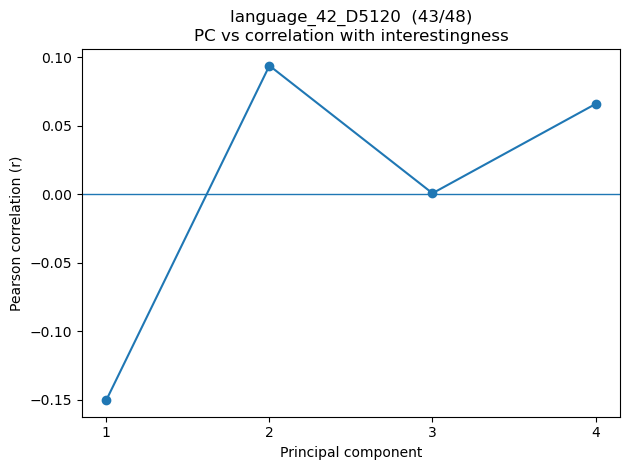

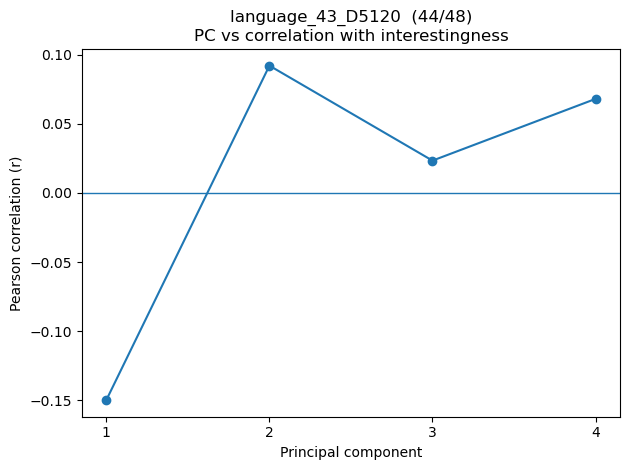

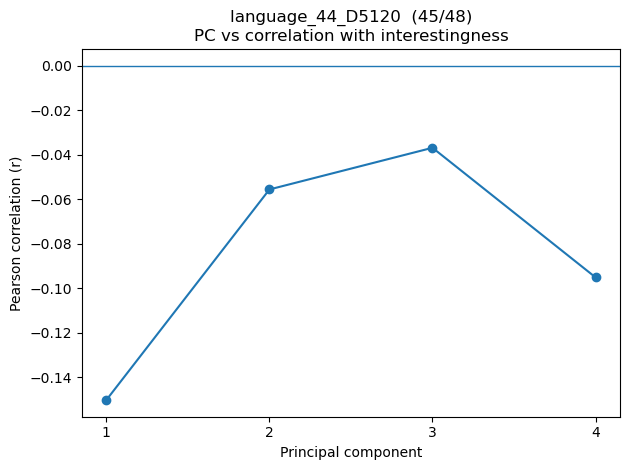

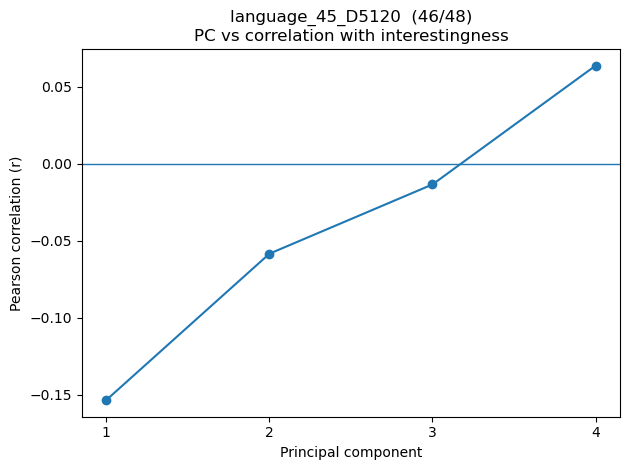

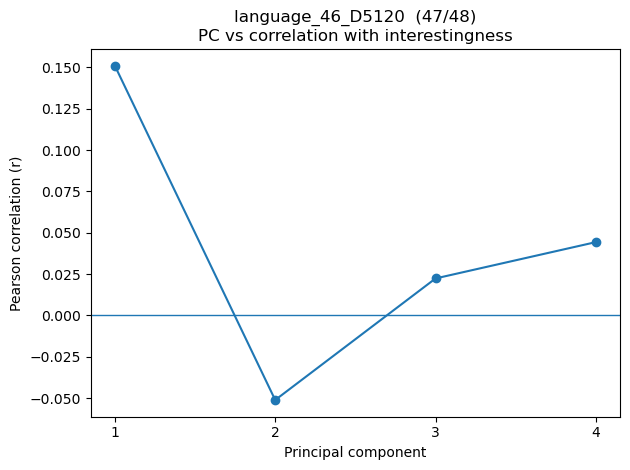

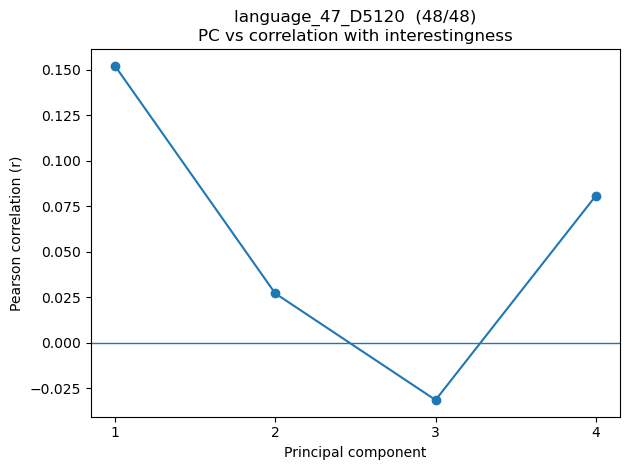

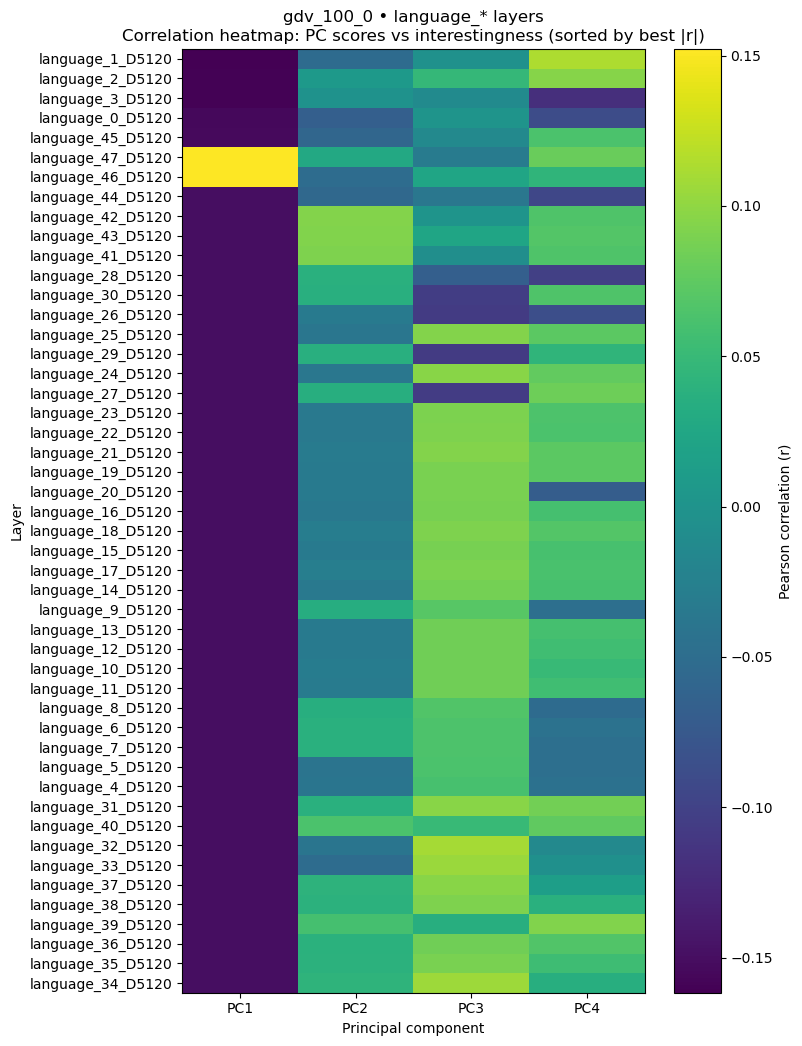


Top layers by |best PC corr|:
  language_1_D5120: best=PC01 r=-0.1617 p=1.21e-01
  language_2_D5120: best=PC01 r=-0.1603 p=1.25e-01
  language_3_D5120: best=PC01 r=-0.1598 p=1.26e-01
  language_0_D5120: best=PC01 r=-0.1551 p=1.38e-01
  language_45_D5120: best=PC01 r=-0.1534 p=1.42e-01
  language_47_D5120: best=PC01 r=+0.1522 p=1.45e-01
  language_46_D5120: best=PC01 r=+0.1510 p=1.48e-01
  language_44_D5120: best=PC01 r=-0.1502 p=1.51e-01
  language_42_D5120: best=PC01 r=-0.1500 p=1.51e-01
  language_43_D5120: best=PC01 r=-0.1499 p=1.52e-01
  language_41_D5120: best=PC01 r=-0.1498 p=1.52e-01
  language_28_D5120: best=PC01 r=-0.1497 p=1.52e-01
  language_30_D5120: best=PC01 r=-0.1497 p=1.52e-01
  language_26_D5120: best=PC01 r=-0.1497 p=1.52e-01
  language_25_D5120: best=PC01 r=-0.1497 p=1.52e-01

Significant (p<0.05) PC-layer cells: 0 / 192


In [4]:
# --- Batch: PC(1..4) vs correlation with interestingness for ALL language_* layers
#     Outputs:
#       (1) one line-plot per layer (≈23/48 etc depending on run)
#       (2) one heatmap (layers x PC index) of correlation coefficients
#       (3) a "Top layers by |best PC corr|" table + optional CSV export
# ---

import os, glob, pickle, re
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# =========================
# CONFIG
# =========================
RESULTS_ROOT = os.environ.get("DASH_RESULTS_ROOT", "./res")
RUN_NAME     = "gdv_100_0"      # None -> first run found
MODALITY     = "language"       # only keys starting with "language_"
METHOD       = "pearson"        # "pearson" or "spearman"
N_PCS        = 4                # we want PC1..PC4
DROP_NAN     = True

# Plot controls
MAKE_PER_LAYER_PLOTS = True     # ~23+ plots
MAKE_HEATMAP         = True     # one summary plot
SHOW_PVAL_STARS      = True     # stars for p<0.05 on per-layer plots

# Optional saving
SAVE_DIR_PLOTS   = None         # e.g. "./pc_corr_language/plots" or None
SAVE_HEATMAP_PNG = None         # e.g. "./pc_corr_language/heatmap.png" or None
SAVE_SUMMARY_CSV = None         # e.g. "./pc_corr_language/summary.csv" or None

# =========================
# Safe unpickler (numpy._core -> numpy.core)
# =========================
class RemappingUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)

def load_pickle_remap(path: str):
    with open(path, "rb") as f:
        return RemappingUnpickler(f).load()

# =========================
# Interestingness extraction
# =========================
def extract_interestingness(ld):
    # 1) explicit numeric interestingness (if present)
    for path in [
        ("samples", "interestingness"),
        ("samples", "interestingness_score"),
        ("samples", "scores"),
        ("interestingness",),
        ("interestingness_score",),
    ]:
        cur = ld
        ok = True
        for p in path:
            if isinstance(cur, dict) and p in cur:
                cur = cur[p]
            else:
                ok = False
                break
        if ok:
            arr = np.asarray(cur).reshape(-1)
            if np.issubdtype(arr.dtype, np.number):
                return arr.astype(float), "stored_numeric"

    # 2) fallback: map labels to 0..4
    labels = None
    if isinstance(ld.get("samples", None), dict):
        labels = ld["samples"].get("labels", None)
    if labels is None:
        labels = ld.get("labels", None)
    if labels is None:
        raise ValueError("No interestingness scores and no labels found.")

    labels = [str(x) for x in labels]
    lab_map = {
        "Not Interesting": 0, "Slightly Interesting": 1, "Moderately Interesting": 2,
        "Very Interesting": 3, "Extremely Interesting": 4,
        # shortened variants
        "Not": 0, "Slightly": 1, "Moderate": 2, "Very": 3, "Extreme": 4,
    }
    y = np.array([lab_map.get(l, np.nan) for l in labels], dtype=float)
    if np.all(~np.isfinite(y)):
        raise ValueError("Labels exist, but none could be mapped to numeric interestingness.")
    return y, "mapped_from_labels"

# =========================
# Reconstruct Z (n_samples x up to PC4) from pairwise PCA views stored as PC12/PC23/PC34 etc
# =========================
def parse_pc_tag(tag: str):
    tag = str(tag).strip()
    if not tag.startswith("PC"):
        return None
    digits = "".join(ch for ch in tag[2:] if ch.isdigit())
    if len(digits) != 2:
        return None
    a, b = int(digits[0]), int(digits[1])
    return a, b

def reconstruct_Z_from_pairwise_views(ld, n_pcs=4):
    pca = ld.get("projections", {}).get("pca", {})
    if not isinstance(pca, dict):
        raise ValueError("No projections.pca dict found.")

    pairs = []
    for tag, d in pca.items():
        if not isinstance(d, dict) or "coords" not in d:
            continue
        ab = parse_pc_tag(tag)
        if ab is None:
            continue
        coords = np.asarray(d["coords"], float)
        if coords.ndim == 2 and coords.shape[1] == 2:
            pairs.append((ab[0], ab[1], tag, coords))

    if not pairs:
        raise ValueError("No pairwise PCA coords found (expected tags like PC12/PC34/etc with 'coords').")

    n = pairs[0][3].shape[0]
    pc_vecs = {}
    pc_src  = {}
    flips   = []

    def set_or_align(pc_idx, vec, src):
        if pc_idx > n_pcs:
            return
        if pc_idx not in pc_vecs:
            pc_vecs[pc_idx] = vec
            pc_src[pc_idx]  = src
            return
        v0 = pc_vecs[pc_idx]
        m = np.isfinite(v0) & np.isfinite(vec)
        if m.sum() < 3:
            return
        r = np.corrcoef(v0[m], vec[m])[0, 1]
        if np.isfinite(r) and r < 0:
            vec = -vec
            flips.append((pc_idx, src, "flipped_to_match"))
        # keep canonical (first) vector; don't overwrite

    for a, b, tag, coords in pairs:
        if coords.shape[0] != n:
            raise ValueError(f"Sample mismatch across PCA coords tags: {tag} has {coords.shape[0]} != {n}")
        set_or_align(a, coords[:, 0].copy(), f"{tag}:x")
        set_or_align(b, coords[:, 1].copy(), f"{tag}:y")

    Z = np.column_stack([pc_vecs.get(i, np.full(n, np.nan)) for i in range(1, n_pcs + 1)])
    meta = {"pc_sources": pc_src, "flips": flips, "available_tags": [t for _, _, t, _ in pairs]}
    return Z, meta

# =========================
# Correlation per PC
# =========================
def corr_per_pc(Z, y, method="pearson", drop_nan=True):
    Z = np.asarray(Z, float)
    y = np.asarray(y, float).reshape(-1)
    if Z.shape[0] != y.shape[0]:
        raise ValueError(f"Z samples {Z.shape[0]} != y samples {y.shape[0]}")

    fn = pearsonr if method.lower() == "pearson" else spearmanr

    corrs = np.full(Z.shape[1], np.nan, float)
    pvals = np.full(Z.shape[1], np.nan, float)

    for k in range(Z.shape[1]):
        x = Z[:, k]
        if drop_nan:
            m = np.isfinite(x) & np.isfinite(y)
            xk, yk = x[m], y[m]
        else:
            xk, yk = x, y

        if len(xk) < 3:
            continue
        if np.isclose(np.std(xk), 0) or np.isclose(np.std(yk), 0):
            continue

        r, p = fn(xk, yk)
        corrs[k] = r
        pvals[k] = p

    return corrs, pvals

# =========================
# Load run + iterate layers
# =========================
pkl_paths = sorted(glob.glob(os.path.join(RESULTS_ROOT, "gdv_*", "gdv.pkl")))
if not pkl_paths:
    raise FileNotFoundError(f"No gdv.pkl found under {RESULTS_ROOT!r} (expected {RESULTS_ROOT}/gdv_*/gdv.pkl)")

if RUN_NAME is None:
    pkl_path = pkl_paths[0]
else:
    cand = [p for p in pkl_paths if os.path.basename(os.path.dirname(p)) == RUN_NAME]
    if not cand:
        raise FileNotFoundError(f"RUN_NAME={RUN_NAME!r} not found. Available: {[os.path.basename(os.path.dirname(p)) for p in pkl_paths]}")
    pkl_path = cand[0]

obj = load_pickle_remap(pkl_path)
run_dir = os.path.basename(os.path.dirname(pkl_path))
print(f"Loaded run: {run_dir}")

layer_keys = [k for k in obj.get("sorted_layers", []) if str(k).startswith(f"{MODALITY}_")]
print(f"Found {len(layer_keys)} {MODALITY}_* layers")

# Make dirs if saving
if SAVE_DIR_PLOTS:
    os.makedirs(SAVE_DIR_PLOTS, exist_ok=True)
if SAVE_HEATMAP_PNG:
    os.makedirs(os.path.dirname(SAVE_HEATMAP_PNG), exist_ok=True)

# Containers for heatmap + ranking
R_mat   = np.full((len(layer_keys), N_PCS), np.nan, float)
P_mat   = np.full((len(layer_keys), N_PCS), np.nan, float)
sources = []
errors  = []

# =========================
# Main loop
# =========================
for i, layer_key in enumerate(layer_keys):
    ld = obj["layer_data"][layer_key]

    try:
        y, y_source = extract_interestingness(ld)
        Z, meta     = reconstruct_Z_from_pairwise_views(ld, n_pcs=N_PCS)
        corrs, pvals = corr_per_pc(Z, y, method=METHOD, drop_nan=DROP_NAN)

        R_mat[i, :] = corrs
        P_mat[i, :] = pvals
        sources.append(y_source)
        errors.append(None)

        if MAKE_PER_LAYER_PLOTS:
            pcs = np.arange(1, N_PCS + 1)

            plt.figure()
            plt.plot(pcs, corrs, marker="o")
            plt.axhline(0, linewidth=1)
            plt.xlabel("Principal component")
            plt.ylabel(f"{METHOD.title()} correlation (r)")
            plt.title(f"{layer_key}  ({i+1}/{len(layer_keys)})\nPC vs correlation with interestingness")
            plt.xticks([1, 2, 3, 4])  # ONLY 1..4 labels, no 0.5 ticks

            if SHOW_PVAL_STARS:
                sig = np.isfinite(pvals) & (pvals < 0.05)
                if np.any(sig):
                    plt.scatter(pcs[sig], np.array(corrs)[sig], marker="*", s=140)

            plt.tight_layout()

            if SAVE_DIR_PLOTS:
                fname = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(layer_key)) + f"__pc_corr_{METHOD}.png"
                plt.savefig(os.path.join(SAVE_DIR_PLOTS, fname), dpi=160, bbox_inches="tight")

            plt.show()

    except Exception as e:
        R_mat[i, :] = np.nan
        P_mat[i, :] = np.nan
        sources.append(None)
        errors.append(repr(e))
        print(f"[WARN] {layer_key}: skipped due to error: {e!r}")

# =========================
# Heatmap (layers x PCs)
# =========================
if MAKE_HEATMAP:
    # sort layers by their best absolute correlation for nicer visualization
    best_abs = np.nanmax(np.abs(R_mat), axis=1)
    order = np.argsort(-best_abs)  # descending

    R_sorted = R_mat[order, :]
    P_sorted = P_mat[order, :]
    layer_sorted = [str(layer_keys[j]) for j in order]

    plt.figure(figsize=(8, max(6, 0.22 * len(layer_sorted))))
    im = plt.imshow(R_sorted, aspect="auto")
    plt.colorbar(im, label=f"{METHOD.title()} correlation (r)")

    plt.xticks(np.arange(N_PCS), [f"PC{i}" for i in range(1, N_PCS + 1)])
    plt.yticks(np.arange(len(layer_sorted)), layer_sorted)
    plt.xlabel("Principal component")
    plt.ylabel("Layer")
    plt.title(f"{run_dir} • {MODALITY}_* layers\nCorrelation heatmap: PC scores vs interestingness (sorted by best |r|)")

    # Optional: annotate significance with a dot
    # (kept light so it doesn't clutter)
    sig = np.isfinite(P_sorted) & (P_sorted < 0.05)
    if np.any(sig):
        ys, xs = np.where(sig)
        plt.scatter(xs, ys, marker="o", s=12)

    plt.tight_layout()

    if SAVE_HEATMAP_PNG:
        plt.savefig(SAVE_HEATMAP_PNG, dpi=180, bbox_inches="tight")

    plt.show()

# =========================
# "Top layers by |best PC corr|" summary
# =========================
summary = []
for i, layer_key in enumerate(layer_keys):
    corrs = R_mat[i, :]
    pvals = P_mat[i, :]
    if np.all(~np.isfinite(corrs)):
        summary.append((str(layer_key), None, np.nan, np.nan))
        continue
    best_i = int(np.nanargmax(np.abs(corrs)))  # 0-based
    summary.append((str(layer_key), best_i + 1, float(corrs[best_i]), float(pvals[best_i])))

summary_valid = [s for s in summary if np.isfinite(s[2])]
summary_valid.sort(key=lambda x: abs(x[2]), reverse=True)

print("\nTop layers by |best PC corr|:")
for layer, pc, r, p in summary_valid[:15]:
    print(f"  {layer}: best=PC{pc:02d} r={r:+.4f} p={p:.2e}")

# Optional CSV export (no pandas required)
if SAVE_SUMMARY_CSV:
    os.makedirs(os.path.dirname(SAVE_SUMMARY_CSV), exist_ok=True)
    with open(SAVE_SUMMARY_CSV, "w", encoding="utf-8") as f:
        f.write("layer,best_pc,best_r,best_p,r_pc1,p_pc1,r_pc2,p_pc2,r_pc3,p_pc3,r_pc4,p_pc4\n")
        for i, (layer, pc, r, p) in enumerate(summary):
            rrow = R_mat[i, :]
            prow = P_mat[i, :]
            f.write(
                f"{layer},{'' if pc is None else pc},{'' if not np.isfinite(r) else r},{'' if not np.isfinite(p) else p},"
                f"{rrow[0]},{prow[0]},{rrow[1]},{prow[1]},{rrow[2]},{prow[2]},{rrow[3]},{prow[3]}\n"
            )
    print(f"\nWrote summary CSV: {SAVE_SUMMARY_CSV}")

# =========================
# Extra: sanity print (how many significant hits)
# =========================
n_sig = int(np.sum(np.isfinite(P_mat) & (P_mat < 0.05)))
print(f"\nSignificant (p<0.05) PC-layer cells: {n_sig} / {len(layer_keys) * N_PCS}")


Loaded run: gdv_100_0
Found 48 language_* layers


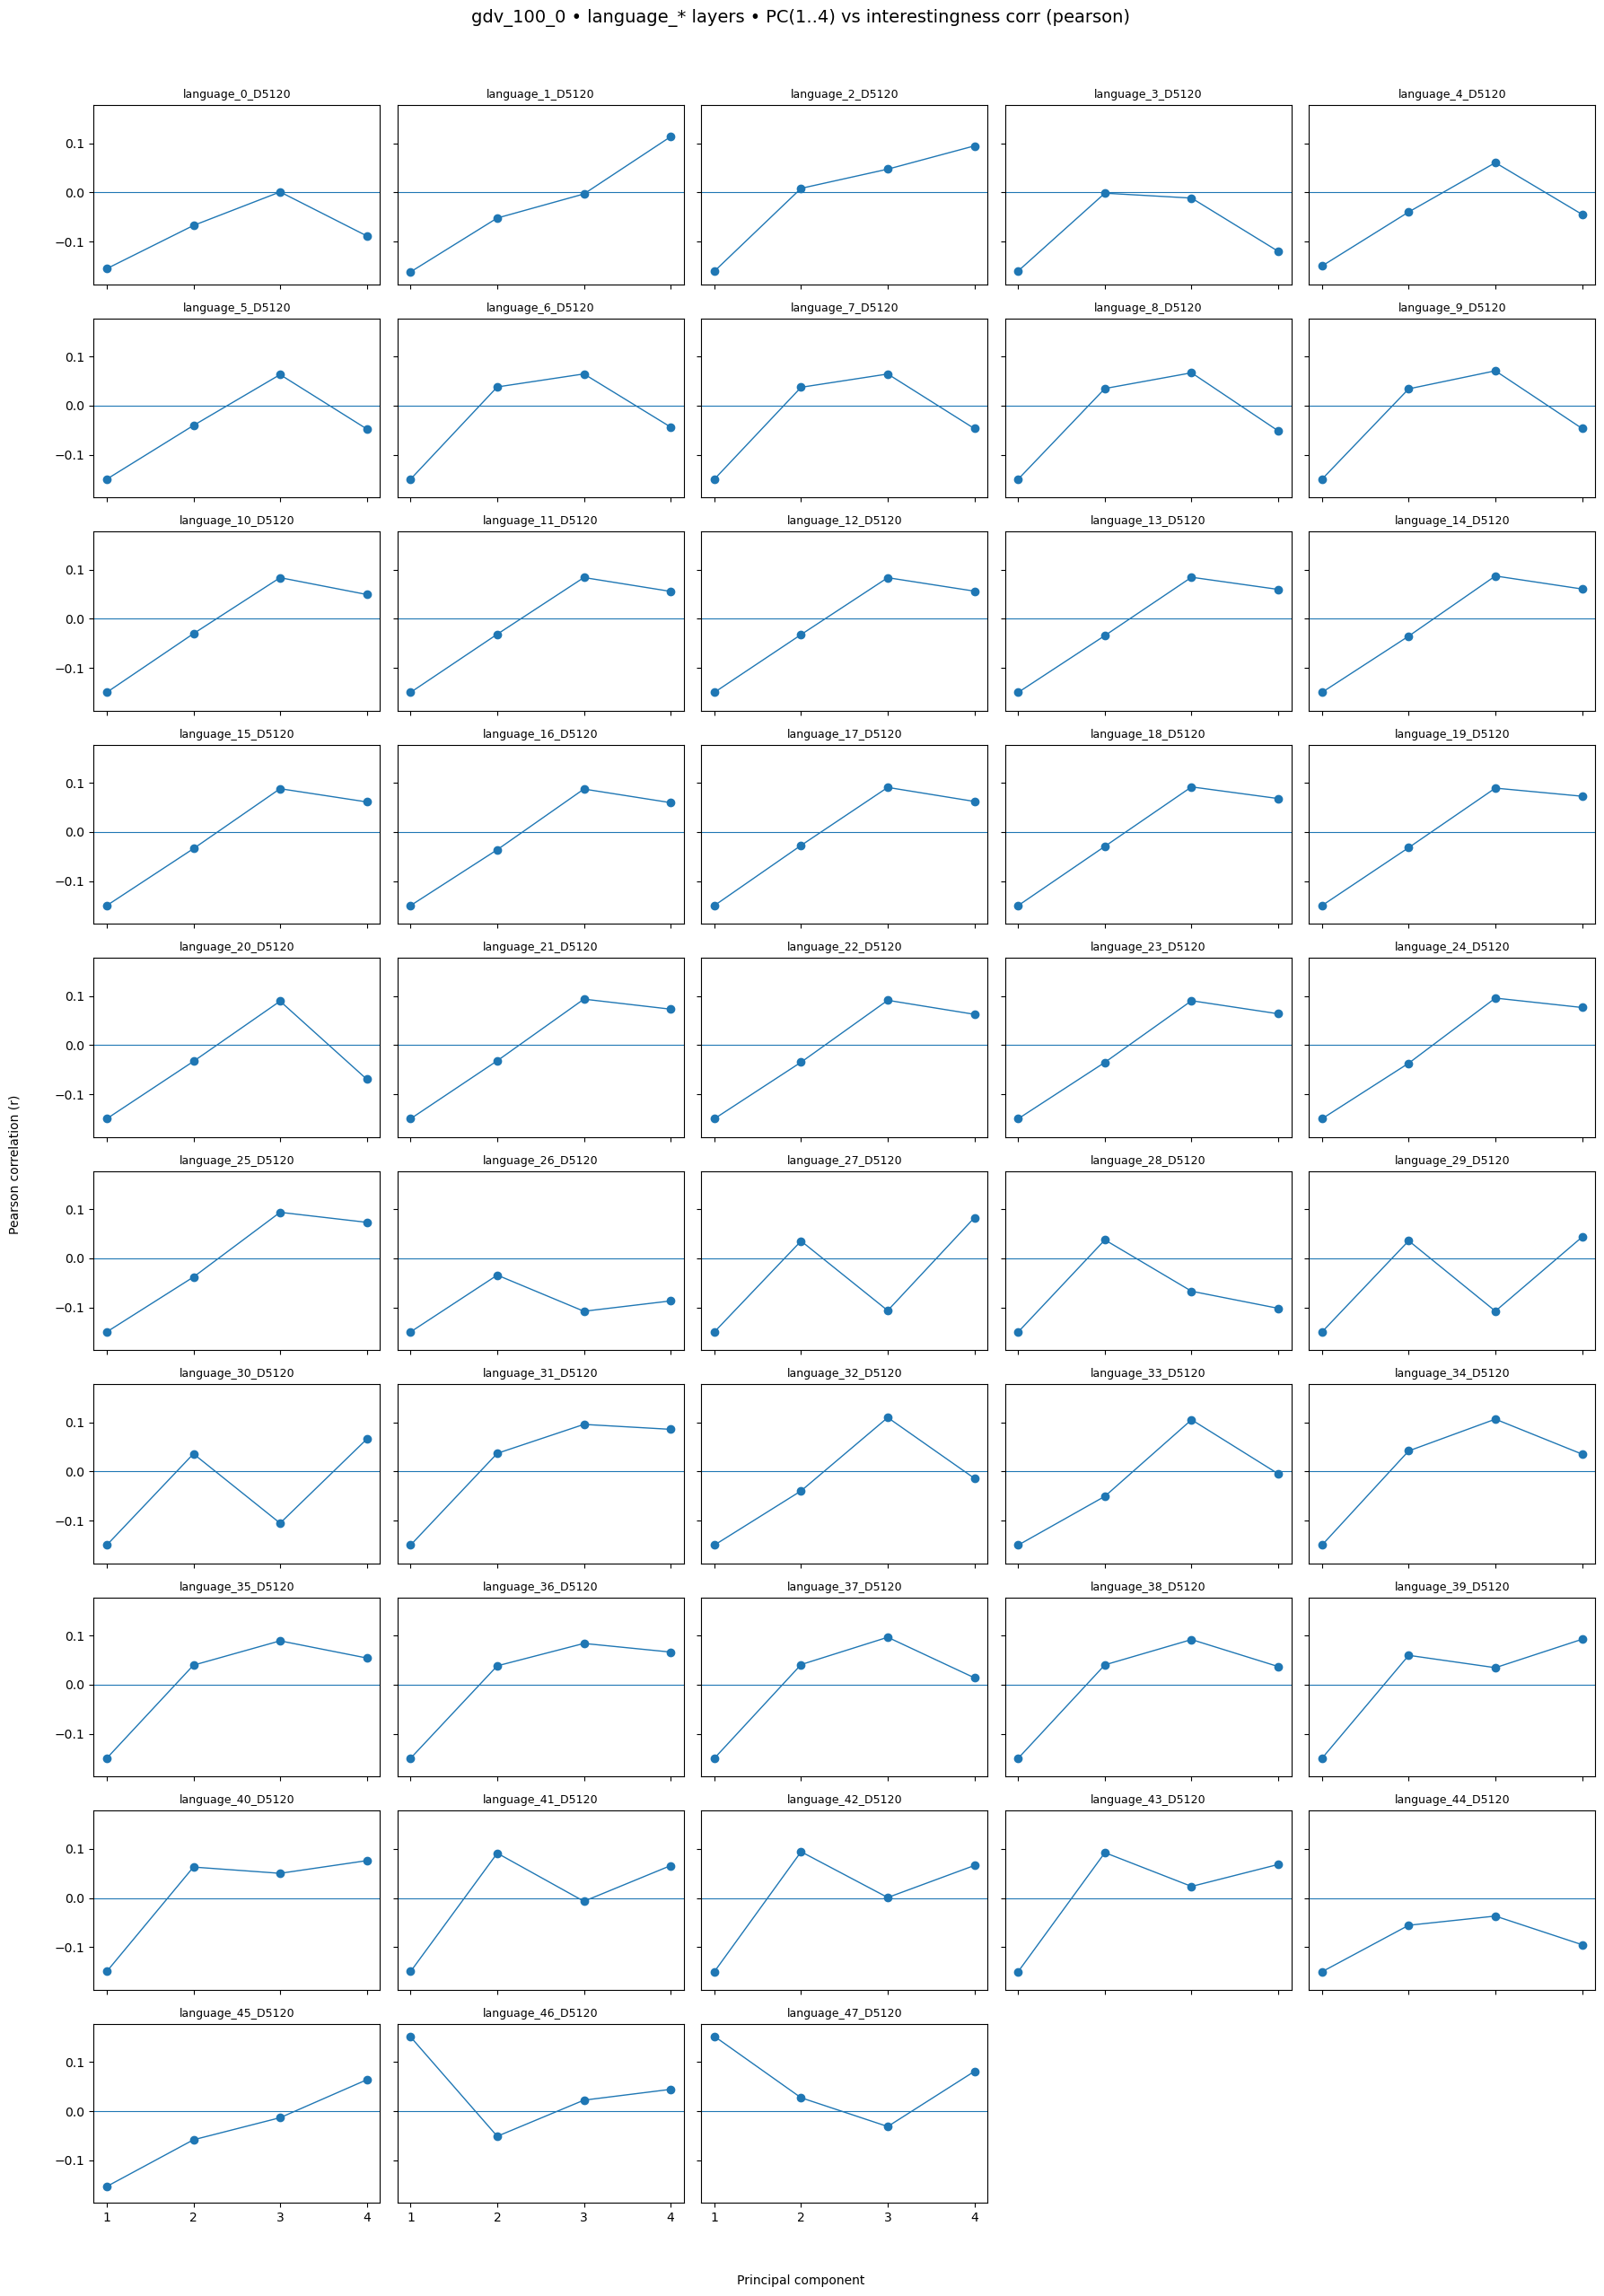

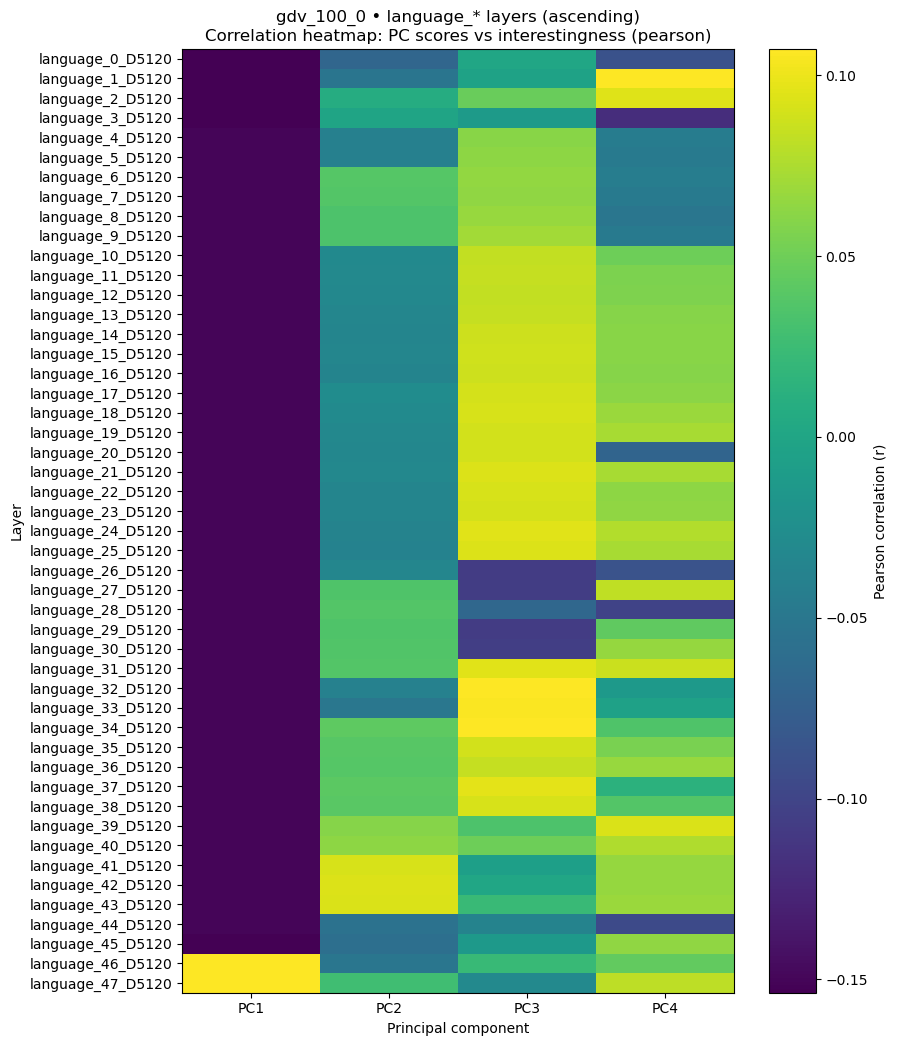


Top layers by |best PC corr|:
  language_1_D5120: best=PC01 r=-0.1617 p=1.21e-01
  language_2_D5120: best=PC01 r=-0.1603 p=1.25e-01
  language_3_D5120: best=PC01 r=-0.1598 p=1.26e-01
  language_0_D5120: best=PC01 r=-0.1551 p=1.38e-01
  language_45_D5120: best=PC01 r=-0.1534 p=1.42e-01
  language_47_D5120: best=PC01 r=+0.1522 p=1.45e-01
  language_46_D5120: best=PC01 r=+0.1510 p=1.48e-01
  language_44_D5120: best=PC01 r=-0.1502 p=1.51e-01
  language_42_D5120: best=PC01 r=-0.1500 p=1.51e-01
  language_43_D5120: best=PC01 r=-0.1499 p=1.52e-01
  language_41_D5120: best=PC01 r=-0.1498 p=1.52e-01
  language_28_D5120: best=PC01 r=-0.1497 p=1.52e-01
  language_30_D5120: best=PC01 r=-0.1497 p=1.52e-01
  language_26_D5120: best=PC01 r=-0.1497 p=1.52e-01
  language_25_D5120: best=PC01 r=-0.1497 p=1.52e-01

Significant (p<0.05) PC-layer cells: 0 / 192


In [7]:
# --- Batch: PC(1..4) vs correlation with interestingness for ALL language_* layers
#     Outputs:
#       (1) one GRID of per-layer line plots (all layers at once)
#       (2) one heatmap (layers x PC index) of correlation coefficients
#       (3) a "Top layers by |best PC corr|" table + optional CSV export
# ---

import os, glob, pickle, re, math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# =========================
# CONFIG
# =========================
RESULTS_ROOT = os.environ.get("DASH_RESULTS_ROOT", "./res")
RUN_NAME     = "gdv_100_0"      # None -> first run found
MODALITY     = "language"       # only keys starting with "language_"
METHOD       = "pearson"        # "pearson" or "spearman"
N_PCS        = 4                # we want PC1..PC4
DROP_NAN     = True

# Plot controls
MAKE_GRID_PLOTS    = True       # one big grid (replaces 23 separate plt.show())
MAKE_HEATMAP       = True       # one summary plot
SHOW_PVAL_STARS    = True       # stars for p<0.05 on per-layer plots

# Grid layout
GRID_NCOLS         = 5          # adjust as you like
GRID_FIG_W         = 18         # inches
GRID_ROW_H         = 2.6        # inches per row

# Heatmap scaling
HEATMAP_SCALE      = "robust"   # "robust" (2..98 pct) or "data" (min..max)

# Optional saving
SAVE_GRID_PNG      = None       # e.g. "./pc_corr_language/grid.png"
SAVE_HEATMAP_PNG   = None       # e.g. "./pc_corr_language/heatmap.png"
SAVE_SUMMARY_CSV   = None       # e.g. "./pc_corr_language/summary.csv"

# =========================
# Safe unpickler (numpy._core -> numpy.core)
# =========================
class RemappingUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)

def load_pickle_remap(path: str):
    with open(path, "rb") as f:
        return RemappingUnpickler(f).load()

# =========================
# Interestingness extraction
# =========================
def extract_interestingness(ld):
    # 1) explicit numeric interestingness (if present)
    for path in [
        ("samples", "interestingness"),
        ("samples", "interestingness_score"),
        ("samples", "scores"),
        ("interestingness",),
        ("interestingness_score",),
    ]:
        cur = ld
        ok = True
        for p in path:
            if isinstance(cur, dict) and p in cur:
                cur = cur[p]
            else:
                ok = False
                break
        if ok:
            arr = np.asarray(cur).reshape(-1)
            if np.issubdtype(arr.dtype, np.number):
                return arr.astype(float), "stored_numeric"

    # 2) fallback: map labels to 0..4
    labels = None
    if isinstance(ld.get("samples", None), dict):
        labels = ld["samples"].get("labels", None)
    if labels is None:
        labels = ld.get("labels", None)
    if labels is None:
        raise ValueError("No interestingness scores and no labels found.")

    labels = [str(x) for x in labels]
    lab_map = {
        "Not Interesting": 0, "Slightly Interesting": 1, "Moderately Interesting": 2,
        "Very Interesting": 3, "Extremely Interesting": 4,
        # shortened variants
        "Not": 0, "Slightly": 1, "Moderate": 2, "Very": 3, "Extreme": 4,
    }
    y = np.array([lab_map.get(l, np.nan) for l in labels], dtype=float)
    if np.all(~np.isfinite(y)):
        raise ValueError("Labels exist, but none could be mapped to numeric interestingness.")
    return y, "mapped_from_labels"

# =========================
# Reconstruct Z (n_samples x up to PC4) from pairwise PCA views stored as PC12/PC23/PC34 etc
# =========================
def parse_pc_tag(tag: str):
    tag = str(tag).strip()
    if not tag.startswith("PC"):
        return None
    digits = "".join(ch for ch in tag[2:] if ch.isdigit())
    if len(digits) != 2:
        return None
    a, b = int(digits[0]), int(digits[1])
    return a, b

def reconstruct_Z_from_pairwise_views(ld, n_pcs=4):
    pca = ld.get("projections", {}).get("pca", {})
    if not isinstance(pca, dict):
        raise ValueError("No projections.pca dict found.")

    pairs = []
    for tag, d in pca.items():
        if not isinstance(d, dict) or "coords" not in d:
            continue
        ab = parse_pc_tag(tag)
        if ab is None:
            continue
        coords = np.asarray(d["coords"], float)
        if coords.ndim == 2 and coords.shape[1] == 2:
            pairs.append((ab[0], ab[1], tag, coords))

    if not pairs:
        raise ValueError("No pairwise PCA coords found (expected tags like PC12/PC34/etc with 'coords').")

    n = pairs[0][3].shape[0]
    pc_vecs = {}
    flips   = []

    def set_or_align(pc_idx, vec, src):
        if pc_idx > n_pcs:
            return
        if pc_idx not in pc_vecs:
            pc_vecs[pc_idx] = vec
            return
        v0 = pc_vecs[pc_idx]
        m = np.isfinite(v0) & np.isfinite(vec)
        if m.sum() < 3:
            return
        r = np.corrcoef(v0[m], vec[m])[0, 1]
        if np.isfinite(r) and r < 0:
            vec = -vec
            flips.append((pc_idx, src, "flipped_to_match"))
        # keep canonical (first) vector; don't overwrite

    for a, b, tag, coords in pairs:
        if coords.shape[0] != n:
            raise ValueError(f"Sample mismatch across PCA coords tags: {tag} has {coords.shape[0]} != {n}")
        set_or_align(a, coords[:, 0].copy(), f"{tag}:x")
        set_or_align(b, coords[:, 1].copy(), f"{tag}:y")

    Z = np.column_stack([pc_vecs.get(i, np.full(n, np.nan)) for i in range(1, n_pcs + 1)])
    meta = {"flips": flips, "available_tags": [t for _, _, t, _ in pairs]}
    return Z, meta

# =========================
# Correlation per PC
# =========================
def corr_per_pc(Z, y, method="pearson", drop_nan=True):
    Z = np.asarray(Z, float)
    y = np.asarray(y, float).reshape(-1)
    if Z.shape[0] != y.shape[0]:
        raise ValueError(f"Z samples {Z.shape[0]} != y samples {y.shape[0]}")

    fn = pearsonr if method.lower() == "pearson" else spearmanr

    corrs = np.full(Z.shape[1], np.nan, float)
    pvals = np.full(Z.shape[1], np.nan, float)

    for k in range(Z.shape[1]):
        x = Z[:, k]
        if drop_nan:
            m = np.isfinite(x) & np.isfinite(y)
            xk, yk = x[m], y[m]
        else:
            xk, yk = x, y

        if len(xk) < 3:
            continue
        if np.isclose(np.std(xk), 0) or np.isclose(np.std(yk), 0):
            continue

        r, p = fn(xk, yk)
        corrs[k] = r
        pvals[k] = p

    return corrs, pvals

# =========================
# Sorting: enforce ascending language_X_... order
# =========================
def layer_index_from_key(k: str) -> int:
    # language_45_D5120 -> 45
    m = re.match(rf"^{re.escape(MODALITY)}_(\d+)_", str(k))
    return int(m.group(1)) if m else 10**9

# =========================
# Load run + iterate layers
# =========================
pkl_paths = sorted(glob.glob(os.path.join(RESULTS_ROOT, "gdv_*", "gdv.pkl")))
if not pkl_paths:
    raise FileNotFoundError(f"No gdv.pkl found under {RESULTS_ROOT!r} (expected {RESULTS_ROOT}/gdv_*/gdv.pkl)")

if RUN_NAME is None:
    pkl_path = pkl_paths[0]
else:
    cand = [p for p in pkl_paths if os.path.basename(os.path.dirname(p)) == RUN_NAME]
    if not cand:
        raise FileNotFoundError(
            f"RUN_NAME={RUN_NAME!r} not found. Available: "
            f"{[os.path.basename(os.path.dirname(p)) for p in pkl_paths]}"
        )
    pkl_path = cand[0]

obj = load_pickle_remap(pkl_path)
run_dir = os.path.basename(os.path.dirname(pkl_path))
print(f"Loaded run: {run_dir}")

layer_keys = [k for k in obj.get("sorted_layers", []) if str(k).startswith(f"{MODALITY}_")]
# ENFORCE ASCENDING BY LAYER NUMBER
layer_keys = sorted(layer_keys, key=layer_index_from_key)

print(f"Found {len(layer_keys)} {MODALITY}_* layers")

# Make dirs if saving
def _mkdir_for(path):
    if path:
        d = os.path.dirname(path)
        if d:
            os.makedirs(d, exist_ok=True)

_mkdir_for(SAVE_GRID_PNG)
_mkdir_for(SAVE_HEATMAP_PNG)
_mkdir_for(SAVE_SUMMARY_CSV)

# Containers for heatmap + ranking
R_mat   = np.full((len(layer_keys), N_PCS), np.nan, float)
P_mat   = np.full((len(layer_keys), N_PCS), np.nan, float)
sources = []
errors  = []

# =========================
# Main loop (compute only)
# =========================
for i, layer_key in enumerate(layer_keys):
    ld = obj["layer_data"][layer_key]
    try:
        y, y_source   = extract_interestingness(ld)
        Z, meta       = reconstruct_Z_from_pairwise_views(ld, n_pcs=N_PCS)
        corrs, pvals  = corr_per_pc(Z, y, method=METHOD, drop_nan=DROP_NAN)

        R_mat[i, :] = corrs
        P_mat[i, :] = pvals
        sources.append(y_source)
        errors.append(None)
    except Exception as e:
        sources.append(None)
        errors.append(repr(e))
        # keep NaNs in matrices
        print(f"[WARN] {layer_key}: skipped due to error: {e!r}")

# =========================
# GRID of per-layer plots (ALL at once)
# =========================
if MAKE_GRID_PLOTS:
    n_layers = len(layer_keys)
    ncols = int(GRID_NCOLS)
    nrows = int(math.ceil(n_layers / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(GRID_FIG_W, GRID_ROW_H * nrows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)

    pcs = np.arange(1, N_PCS + 1)

    # Data-driven y-limits (so it doesn't look flat)
    ymin, ymax = np.nanmin(R_mat), np.nanmax(R_mat)
    if not np.isfinite(ymin) or not np.isfinite(ymax) or np.isclose(ymin, ymax):
        ymin, ymax = -0.1, 0.1
    pad = 0.08 * (ymax - ymin) if (np.isfinite(ymax - ymin) and not np.isclose(ymax, ymin)) else 0.02
    ylo, yhi = ymin - pad, ymax + pad

    for ax_i, ax in enumerate(axes):
        if ax_i >= n_layers:
            ax.axis("off")
            continue

        layer_key = layer_keys[ax_i]
        corrs = R_mat[ax_i, :]
        pvals = P_mat[ax_i, :]

        ax.plot(pcs, corrs, marker="o", linewidth=1)
        ax.axhline(0, linewidth=0.8)
        ax.set_xticks([1, 2, 3, 4])  # ONLY 1..4 labels
        ax.set_ylim(ylo, yhi)

        # stars for p<0.05
        if SHOW_PVAL_STARS:
            sig = np.isfinite(pvals) & (pvals < 0.05)
            if np.any(sig):
                ax.scatter(pcs[sig], np.array(corrs)[sig], marker="*", s=60)

        # short title: language_12
        ax.set_title(str(layer_key), fontsize=9)

    fig.suptitle(
        f"{run_dir} • {MODALITY}_* layers • PC(1..{N_PCS}) vs interestingness corr ({METHOD})",
        fontsize=14, y=0.995
    )
    # common labels
    fig.text(0.5, 0.02, "Principal component", ha="center")
    fig.text(0.01, 0.5, f"{METHOD.title()} correlation (r)", va="center", rotation="vertical")

    plt.tight_layout(rect=[0.03, 0.04, 1, 0.98])

    if SAVE_GRID_PNG:
        plt.savefig(SAVE_GRID_PNG, dpi=180, bbox_inches="tight")
        print(f"[saved] Grid PNG: {SAVE_GRID_PNG}")

    plt.show()

# =========================
# Heatmap (layers x PCs) — keep ASCENDING layer order
# =========================
if MAKE_HEATMAP:
    R_sorted = R_mat
    P_sorted = P_mat
    layer_sorted = [str(k) for k in layer_keys]

    # choose heatmap scaling (DO NOT hard clamp to [-1,1])
    if HEATMAP_SCALE == "robust":
        vmin, vmax = np.nanpercentile(R_sorted, [2, 98])
        if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
            vmin, vmax = np.nanmin(R_sorted), np.nanmax(R_sorted)
    else:
        vmin, vmax = np.nanmin(R_sorted), np.nanmax(R_sorted)

    # fallback if everything is nan / constant
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
        vmin, vmax = -0.1, 0.1

    plt.figure(figsize=(9, max(6, 0.22 * len(layer_sorted))))
    im = plt.imshow(R_sorted, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(im, label=f"{METHOD.title()} correlation (r)")

    plt.xticks(np.arange(N_PCS), [f"PC{i}" for i in range(1, N_PCS + 1)])
    plt.yticks(np.arange(len(layer_sorted)), layer_sorted)
    plt.xlabel("Principal component")
    plt.ylabel("Layer")
    plt.title(
        f"{run_dir} • {MODALITY}_* layers (ascending)\n"
        f"Correlation heatmap: PC scores vs interestingness ({METHOD})"
    )

    # optional: mark p<0.05 with dots (light)
    sig = np.isfinite(P_sorted) & (P_sorted < 0.05)
    if np.any(sig):
        ys, xs = np.where(sig)
        plt.scatter(xs, ys, marker="o", s=12)

    plt.tight_layout()

    if SAVE_HEATMAP_PNG:
        plt.savefig(SAVE_HEATMAP_PNG, dpi=180, bbox_inches="tight")
        print(f"[saved] Heatmap PNG: {SAVE_HEATMAP_PNG}")

    plt.show()

# =========================
# "Top layers by |best PC corr|" summary
# =========================
summary = []
for i, layer_key in enumerate(layer_keys):
    corrs = R_mat[i, :]
    pvals = P_mat[i, :]
    if np.all(~np.isfinite(corrs)):
        summary.append((str(layer_key), None, np.nan, np.nan))
        continue
    best_i = int(np.nanargmax(np.abs(corrs)))  # 0-based
    summary.append((str(layer_key), best_i + 1, float(corrs[best_i]), float(pvals[best_i])))

summary_valid = [s for s in summary if np.isfinite(s[2])]
summary_valid.sort(key=lambda x: abs(x[2]), reverse=True)

print("\nTop layers by |best PC corr|:")
for layer, pc, r, p in summary_valid[:15]:
    print(f"  {layer}: best=PC{pc:02d} r={r:+.4f} p={p:.2e}")

# Optional CSV export (no pandas required)
if SAVE_SUMMARY_CSV:
    _mkdir_for(SAVE_SUMMARY_CSV)
    with open(SAVE_SUMMARY_CSV, "w", encoding="utf-8") as f:
        f.write("layer,best_pc,best_r,best_p,r_pc1,p_pc1,r_pc2,p_pc2,r_pc3,p_pc3,r_pc4,p_pc4\n")
        for i, (layer, pc, r, p) in enumerate(summary):
            rrow = R_mat[i, :]
            prow = P_mat[i, :]
            f.write(
                f"{layer},{'' if pc is None else pc},{'' if not np.isfinite(r) else r},{'' if not np.isfinite(p) else p},"
                f"{rrow[0]},{prow[0]},{rrow[1]},{prow[1]},{rrow[2]},{prow[2]},{rrow[3]},{prow[3]}\n"
            )
    print(f"\nWrote summary CSV: {SAVE_SUMMARY_CSV}")

# =========================
# Extra sanity print
# =========================
n_sig = int(np.sum(np.isfinite(P_mat) & (P_mat < 0.05)))
print(f"\nSignificant (p<0.05) PC-layer cells: {n_sig} / {len(layer_keys) * N_PCS}")
